<a href="https://colab.research.google.com/github/Olivia50066/Olivia50066/blob/main/F2379_CH05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#第5章：機器學習的基礎

##5-1 普適化：機器學習的終極目標

###5-1-1 低度配適與過度配適

####程式 5.1 在MNIST資料集中新增維度

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(train_images, train_labels), _ = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


####程式 5.2 用新的資料集來分別訓練模型

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer=keras.optimizers.RMSprop(1.),
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1077 - loss: 3051.7585 - val_accuracy: 0.0997 - val_loss: 2.3720
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.1020 - loss: 3.4799 - val_accuracy: 0.0995 - val_loss: 2.4803
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.0997 - loss: 2.4537 - val_accuracy: 0.1003 - val_loss: 2.4986
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.0997 - loss: 2.4526 - val_accuracy: 0.1003 - val_loss: 2.4958
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.0974 - loss: 2.4560 - val_accuracy: 0.0983 - val_loss: 2.4346
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.1010 - loss: 2.4509 - val_accuracy: 0.0957 - val_loss: 2.4613
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.1002 - loss: 2.4540 - val_accuracy: 0.1003 - val_loss: 2.3765
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.0978 - loss: 2.4556 - val

####程式 5.3 繪製驗證準確度以進行比較

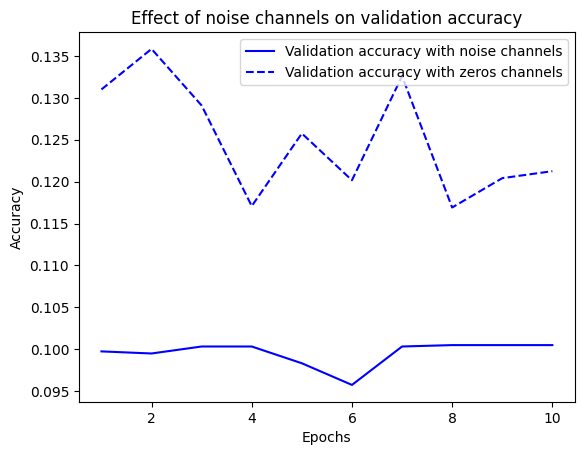

In [ ]:
import matplotlib.pyplot as plt
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
    label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
    label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

###5-1-2 普適化在深度學習中的本質

####程式 5.4 訓練模型來擬合標籤打亂後的MNIST資料集

In [ ]:
(train_images, train_labels), _ = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:].copy()
np.random.shuffle(random_train_labels)

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer="rmsprop",
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
model.fit(train_images, random_train_labels,
     epochs=100,
     batch_size=128,
     validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0995 - loss: 2.3219 - val_accuracy: 0.1007 - val_loss: 2.3036
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1056 - loss: 2.3041 - val_accuracy: 0.0964 - val_loss: 2.3076
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1062 - loss: 2.3031 - val_accuracy: 0.1035 - val_loss: 2.3070
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1111 - loss: 2.3006 - val_accuracy: 0.1036 - val_loss: 2.3095
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1128 - loss: 2.2983 - val_accuracy: 0.0970 - val_loss: 2.3214
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1191 - loss: 2.2942 - val_accuracy: 0.1016 - val_loss: 2.3196
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1235 - loss: 2.2889 - val_accuracy: 0.1020 - val_loss: 2.3192
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1305 - loss: 2.2815 - val_ac

##5-3 提升模型的擬合表現

###5-3-1 調整梯度下降的關鍵參數

####程式 5.7 使用過高的學習率來訓練MNIST模型

In [ ]:
(train_images, train_labels), _ = fashion_mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer="rmsprop",
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
model.fit(train_images, train_labels,
     epochs=10,
     batch_size=128,
     validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7927 - loss: 0.5902 - val_accuracy: 0.8393 - val_loss: 0.4408
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8535 - loss: 0.4036 - val_accuracy: 0.8573 - val_loss: 0.4058
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8698 - loss: 0.3548 - val_accuracy: 0.8727 - val_loss: 0.3495
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8800 - loss: 0.3228 - val_accuracy: 0.8737 - val_loss: 0.3477
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8876 - loss: 0.3021 - val_accuracy: 0.8806 - val_loss: 0.3288
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8940 - loss: 0.2845 - val_accuracy: 0.8731 - val_loss: 0.3520
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8987 - loss: 0.2723 - val_accuracy: 0.8913 - val_loss: 0.3081
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9039 - loss: 0.2577 - val_accura

####程式 5.8 使用合理的學習率來訓練相同模型

In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer=keras.optimizers.RMSprop(1.0),
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2213 - loss: 911.1755 - val_accuracy: 0.1172 - val_loss: 2.5594
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1123 - loss: 2.5058 - val_accuracy: 0.1126 - val_loss: 2.4369
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1200 - loss: 2.4036 - val_accuracy: 0.1177 - val_loss: 2.5231
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1309 - loss: 2.3804 - val_accuracy: 0.1347 - val_loss: 2.4100
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1354 - loss: 2.4542 - val_accuracy: 0.1238 - val_loss: 2.4966
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1285 - loss: 2.3788 - val_accuracy: 0.1217 - val_loss: 2.5080
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1387 - loss: 2.4705 - val_accuracy: 0.1612 - val_loss: 3.6524
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1357 - loss: 2.6529 - val_acc

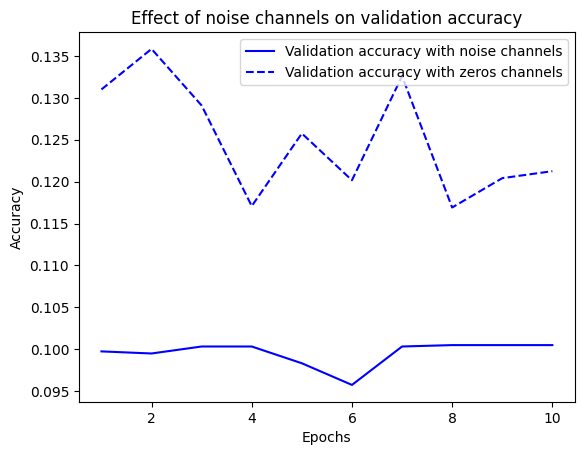

In [ ]:
import matplotlib.pyplot as plt
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
    label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
    label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
#學習率1
model_learning_rate_1 = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_learning_rate_1.compile(optimizer=keras.optimizers.RMSprop(1.0),
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
result_learning_rate_1 = model_learning_rate_1.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1986 - loss: 1012.8564 - val_accuracy: 0.1325 - val_loss: 2.4518
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1266 - loss: 2.7226 - val_accuracy: 0.1284 - val_loss: 2.4989
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1252 - loss: 2.4070 - val_accuracy: 0.0994 - val_loss: 2.3815
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1240 - loss: 2.3958 - val_accuracy: 0.1403 - val_loss: 2.5968
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1335 - loss: 2.5898 - val_accuracy: 0.1264 - val_loss: 2.3133
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1269 - loss: 2.3888 - val_accuracy: 0.1257 - val_loss: 2.3784
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1353 - loss: 2.3635 - val_accuracy: 0.1423 - val_loss: 2.4436
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1275 - loss: 2.4015 - val_accur

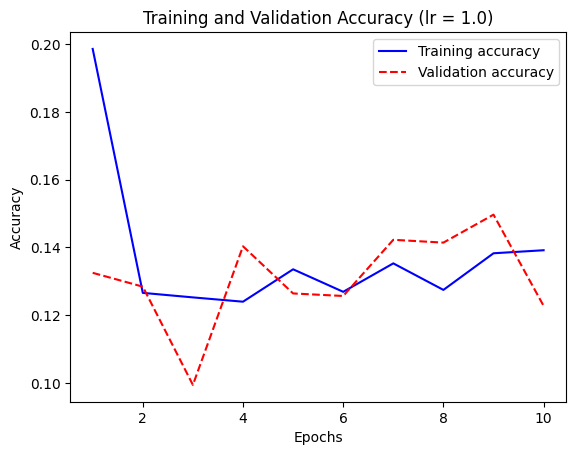

In [ ]:
#學習率1的圖
import matplotlib.pyplot as plt
val_acc_1 = result_learning_rate_1.history["accuracy"]
val_acc_1r = result_learning_rate_1.history["val_accuracy"]

epochs = range(1, len(val_acc_1) + 1)

plt.plot(epochs, val_acc_1, "b-", label="Training accuracy")
plt.plot(epochs, val_acc_1r, "r--", label="Validation accuracy")

plt.title("Training and Validation Accuracy (lr = 1.0)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#學習率0.1
model_learning_rate_01 = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_learning_rate_01.compile(optimizer=keras.optimizers.RMSprop(0.1),
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
result_learning_rate_01 = model_learning_rate_01.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5466 - loss: 12.5072 - val_accuracy: 0.5713 - val_loss: 1.1144
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6073 - loss: 1.2501 - val_accuracy: 0.5826 - val_loss: 1.1382
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6251 - loss: 1.2291 - val_accuracy: 0.6545 - val_loss: 1.0170
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6253 - loss: 1.1584 - val_accuracy: 0.5627 - val_loss: 1.1375
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6350 - loss: 1.1409 - val_accuracy: 0.5306 - val_loss: 1.5441
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6323 - loss: 1.1252 - val_accuracy: 0.6338 - val_loss: 1.0756
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5973 - loss: 1.1816 - val_accuracy: 0.5673 - val_loss: 1.2304
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5594 - loss: 1.2674 - val_accuracy

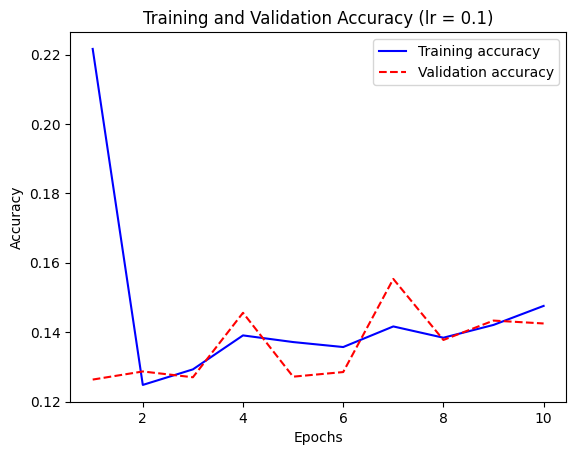

In [ ]:
#學習率0.1的圖
import matplotlib.pyplot as plt
val_acc_01 = result_learning_rate_1.history["accuracy"]
val_acc_01r = result_learning_rate_1.history["val_accuracy"]

epochs = range(1, len(val_acc_1) + 1)

plt.plot(epochs, val_acc_01, "b-", label="Training accuracy")
plt.plot(epochs, val_acc_01r, "r--", label="Validation accuracy")

plt.title("Training and Validation Accuracy (lr = 0.1)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#學習率0.01
model_learning_rate_001 = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_learning_rate_001.compile(optimizer=keras.optimizers.RMSprop(0.01),
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
result_learning_rate_001 = model_learning_rate_001.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7538 - loss: 0.9235 - val_accuracy: 0.7985 - val_loss: 0.6403
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8345 - loss: 0.4559 - val_accuracy: 0.8470 - val_loss: 0.4289
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8520 - loss: 0.4177 - val_accuracy: 0.8373 - val_loss: 0.5048
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8590 - loss: 0.3904 - val_accuracy: 0.8547 - val_loss: 0.4079
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8681 - loss: 0.3759 - val_accuracy: 0.8743 - val_loss: 0.3866
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8714 - loss: 0.3585 - val_accuracy: 0.8686 - val_loss: 0.3973
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8755 - loss: 0.3435 - val_accuracy: 0.8626 - val_loss: 0.4973
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8797 - loss: 0.3359 - val_accuracy

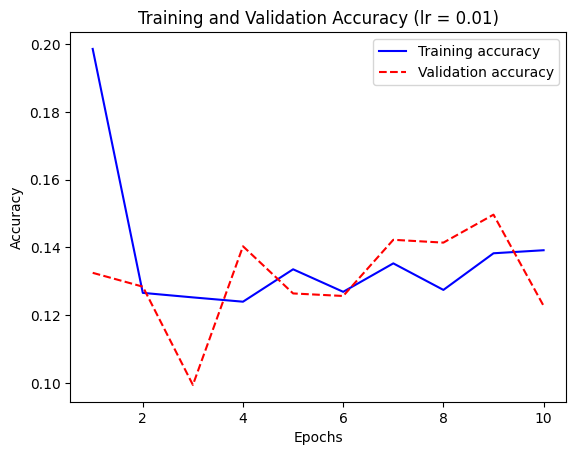

In [ ]:
#學習率0.01的圖
import matplotlib.pyplot as plt
val_acc_001 = result_learning_rate_1.history["accuracy"]
val_acc_001r = result_learning_rate_1.history["val_accuracy"]

epochs = range(1, len(val_acc_1) + 1)

plt.plot(epochs, val_acc_001, "b-", label="Training accuracy")
plt.plot(epochs, val_acc_001r, "r--", label="Validation accuracy")

plt.title("Training and Validation Accuracy (lr = 0.01)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

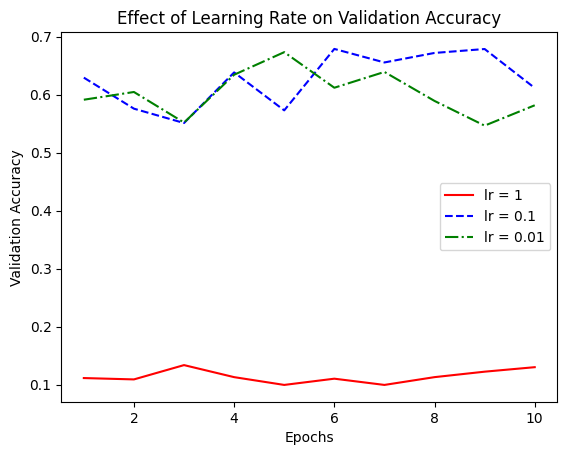

In [ ]:
# 三種 learning rate 的 val_accuracy and accuracy 圖
# result_learning_rate_1
# result_learning_rate_01
# result_learning_rate_001
import matplotlib.pyplot as plt

val_acc_1 = result_learning_rate_1.history["val_accuracy"]
val_acc_01 = result_learning_rate_01.history["val_accuracy"]
val_acc_001 = result_learning_rate_001.history["val_accuracy"]

epochs = range(1, len(val_acc_1) + 1)

plt.plot(epochs, val_acc_1, "r-", label="lr = 1")
plt.plot(epochs, val_acc_01, "b--", label="lr = 0.1")
plt.plot(epochs, val_acc_001, "g-.", label="lr = 0.01")

plt.title("Effect of Learning Rate on Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

###5-3-3 提升模型容量(capacity)

####程式 5.9 使用MNIST資料集訓練小模型

In [ ]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(optimizer="rmsprop",
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7608 - loss: 0.7270 - val_accuracy: 0.8027 - val_loss: 0.5610
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.5122 - val_accuracy: 0.8309 - val_loss: 0.4921
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8387 - loss: 0.4734 - val_accuracy: 0.8408 - val_loss: 0.4670
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8456 - loss: 0.4535 - val_accuracy: 0.8434 - val_loss: 0.4548
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8507 - loss: 0.4412 - val_accuracy: 0.8462 - val_loss: 0.4446
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8524 - loss: 0.4317 - val_accuracy: 0.8526 - val_loss: 0.4367
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8555 - loss: 0.4243 - val_accuracy: 0.8496 - val_loss: 0.4394
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8570 - loss: 0.4188 - val_accuracy: 0.

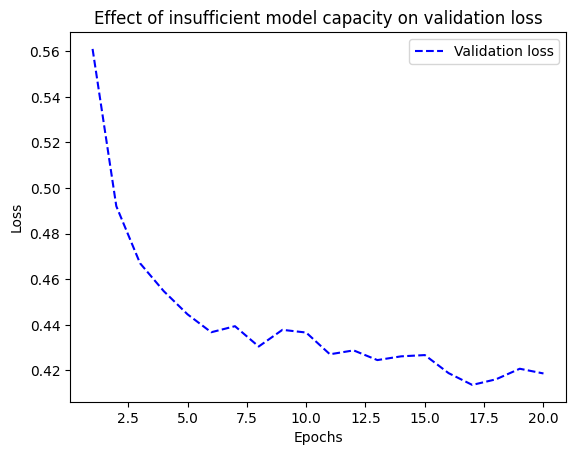

In [ ]:
import matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
    label="Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [ ]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="rmsprop",
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7846 - loss: 0.6114 - val_accuracy: 0.8255 - val_loss: 0.4774
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8480 - loss: 0.4177 - val_accuracy: 0.8640 - val_loss: 0.3820
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8643 - loss: 0.3714 - val_accuracy: 0.8634 - val_loss: 0.3871
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8740 - loss: 0.3430 - val_accuracy: 0.8700 - val_loss: 0.3553
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8814 - loss: 0.3206 - val_accuracy: 0.8805 - val_loss: 0.3307
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8871 - loss: 0.3029 - val_accuracy: 0.8808 - val_loss: 0.3340
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8925 - loss: 0.2916 - val_accuracy: 0.8800 - val_loss: 0.3360
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8960 - loss: 0.2802 - val_accuracy: 0.

##5-4 提升普適化能力

###5-4-4 將模型常規化

####程式 5.10 原始模型

In [ ]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
train_data = vectorize_sequences(train_data)

model = keras.Sequential([
    layers.Dense(16, activation="relu"),  # 16 單元的 Dense Layer
    layers.Dense(16, activation="relu"),  # 16 單元的 Dense Layer
    layers.Dense(1, activation="sigmoid") # 1 單元的 Output Layer
])
model.compile(optimizer="rmsprop",
       loss="binary_crossentropy",  # 二元結果使用的 loss function
       metrics=["accuracy"])
history_original = model.fit(train_data, train_labels,
                epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7771 - loss: 0.5134 - val_accuracy: 0.8416 - val_loss: 0.4064
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8961 - loss: 0.3156 - val_accuracy: 0.8675 - val_loss: 0.3367
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9233 - loss: 0.2373 - val_accuracy: 0.8832 - val_loss: 0.2936
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9351 - loss: 0.1931 - val_accuracy: 0.8887 - val_loss: 0.2764
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9474 - loss: 0.1612 - val_accuracy: 0.8869 - val_loss: 0.2822
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9583 - loss: 0.1341 - val_accuracy: 0.8790 - val_loss: 0.3083
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9641 - loss: 0.1167 - val_accuracy: 0.8851 - val_loss: 0.3019
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9712 - loss: 0.0995 - val_accuracy: 0.8818 - v

####程式 5.11 容量較小的模型版本

In [ ]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
       loss="binary_crossentropy",
       metrics=["accuracy"])
history_smaller_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6382 - loss: 0.6400 - val_accuracy: 0.7363 - val_loss: 0.5916
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7759 - loss: 0.5554 - val_accuracy: 0.8071 - val_loss: 0.5341
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8403 - loss: 0.4987 - val_accuracy: 0.8268 - val_loss: 0.4934
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8754 - loss: 0.4544 - val_accuracy: 0.8429 - val_loss: 0.4664
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8997 - loss: 0.4186 - val_accuracy: 0.8672 - val_loss: 0.4418
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9175 - loss: 0.3884 - val_accuracy: 0.8629 - val_loss: 0.4305
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9319 - loss: 0.3621 - val_accuracy: 0.8723 - val_loss: 0.4163
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9440 - loss: 0.3376 - val_accuracy: 0.8800 - v

####程式 5.12 具有更高容量的模型版本

In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
       loss="binary_crossentropy",
       metrics=["accuracy"])
history_larger_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - accuracy: 0.7181 - loss: 0.5685 - val_accuracy: 0.8511 - val_loss: 0.3629
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 314ms/step - accuracy: 0.8662 - loss: 0.3242 - val_accuracy: 0.8859 - val_loss: 0.2805
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step - accuracy: 0.9086 - loss: 0.2280 - val_accuracy: 0.8698 - val_loss: 0.3121
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 302ms/step - accuracy: 0.9279 - loss: 0.1874 - val_accuracy: 0.8522 - val_loss: 0.3781
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step - accuracy: 0.9453 - loss: 0.1457 - val_accuracy: 0.8786 - val_loss: 0.2940
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step - accuracy: 0.9658 - loss: 0.1004 - val_accuracy: 0.8865 - val_loss: 0.3282
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step - accuracy: 0.9703 - loss: 0.0913 - val_accuracy: 0.8847 - val_loss: 0.3457
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 302ms/step - accuracy: 0.9775 - loss: 0.0732 - val_accuracy

####程式 5.13 將L2常規化加入模型中

In [ ]:
from tensorflow.keras import regularizers
model = keras.Sequential([
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_l2_reg = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7793 - loss: 0.6186 - val_accuracy: 0.8560 - val_loss: 0.4896
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8904 - loss: 0.4163 - val_accuracy: 0.8635 - val_loss: 0.4254
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9128 - loss: 0.3408 - val_accuracy: 0.8806 - val_loss: 0.3803
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9268 - loss: 0.2980 - val_accuracy: 0.8672 - val_loss: 0.4014
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9329 - loss: 0.2767 - val_accuracy: 0.8819 - val_loss: 0.3658
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9344 - loss: 0.2669 - val_accuracy: 0.8859 - val_loss: 0.3595
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9430 - loss: 0.2491 - val_accuracy: 0.8841 - val_loss: 0.3646
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9457 - loss: 0.2418 - val_accuracy: 0.8823 - v

In [ ]:
from tensorflow.keras import regularizers
model = keras.Sequential([
    layers.Dense(16,
                 kernel_regularizer=regularizers.l1(0.002),
                 activation="relu"),
    layers.Dense(16,
                 kernel_regularizer=regularizers.l1(0.002),
                 activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_l1_reg = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6948 - loss: 1.5668 - val_accuracy: 0.8127 - val_loss: 0.8966
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7949 - loss: 0.8644 - val_accuracy: 0.8267 - val_loss: 0.8383
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8187 - loss: 0.8113 - val_accuracy: 0.8326 - val_loss: 0.8044
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8253 - loss: 0.7823 - val_accuracy: 0.8384 - val_loss: 0.7796
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8313 - loss: 0.7611 - val_accuracy: 0.8389 - val_loss: 0.7556
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8359 - loss: 0.7435 - val_accuracy: 0.8376 - val_loss: 0.7445
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8403 - loss: 0.7271 - val_accuracy: 0.8135 - val_loss: 0.7648
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8444 - loss: 0.7111 - val_accuracy: 0.8457 - v

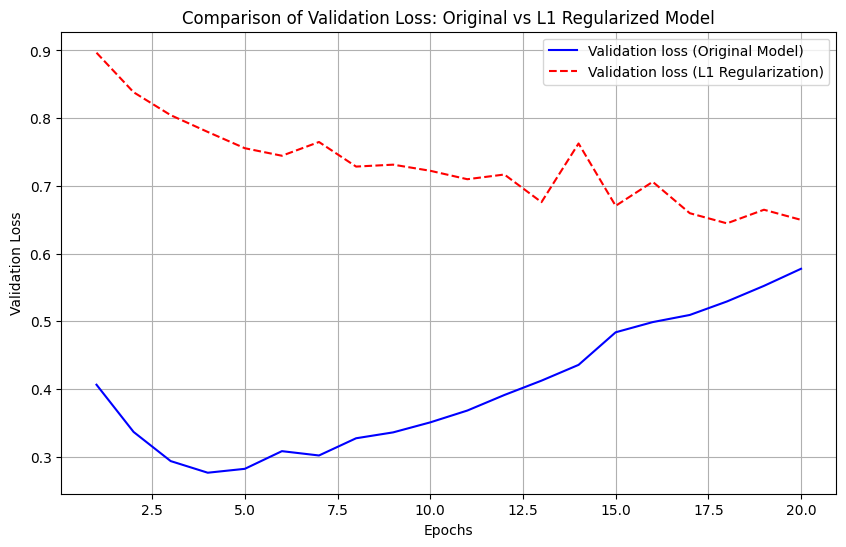

In [ ]:
import matplotlib.pyplot as plt

val_loss_original = history_original.history["val_loss"]
val_loss_l1_reg = history_l1_reg.history["val_loss"]

epochs = range(1, len(val_loss_original) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss_original, "b-", label="Validation loss (Original Model)")
plt.plot(epochs, val_loss_l1_reg, "r--", label="Validation loss (L1 Regularization)")

plt.title("Comparison of Validation Loss: Original vs L1 Regularized Model")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

####程式 5.14 Keras提供不同的權重常規化物件

In [ ]:
from tensorflow.keras import regularizers
regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

####程式 5.15 將Dropout層添加到IMDB神經網路

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6459 - loss: 0.6281 - val_accuracy: 0.8399 - val_loss: 0.5258
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7774 - loss: 0.5074 - val_accuracy: 0.8614 - val_loss: 0.4211
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8323 - loss: 0.4260 - val_accuracy: 0.8757 - val_loss: 0.3521
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8687 - loss: 0.3582 - val_accuracy: 0.8808 - val_loss: 0.3059
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8855 - loss: 0.3180 - val_accuracy: 0.8884 - val_loss: 0.2903
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9040 - loss: 0.2740 - val_accuracy: 0.8828 - val_loss: 0.2866
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9165 - loss: 0.2415 - val_accuracy: 0.8913 - val_loss: 0.2755
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9295 - loss: 0.2177 - val_accuracy: 0.8905 - v

In [ ]:
# dropout 0.3
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout_03 = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7197 - loss: 0.5828 - val_accuracy: 0.8576 - val_loss: 0.4421
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8470 - loss: 0.4155 - val_accuracy: 0.8777 - val_loss: 0.3499
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8849 - loss: 0.3322 - val_accuracy: 0.8883 - val_loss: 0.2968
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9050 - loss: 0.2757 - val_accuracy: 0.8920 - val_loss: 0.2826
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9219 - loss: 0.2306 - val_accuracy: 0.8912 - val_loss: 0.2751
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9344 - loss: 0.2017 - val_accuracy: 0.8839 - val_loss: 0.2815
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9437 - loss: 0.1754 - val_accuracy: 0.8897 - val_loss: 0.2792
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9534 - loss: 0.1503 - val_accuracy: 0.8895 - v

In [ ]:
# dropout 0.5
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout_05 = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6187 - loss: 0.6420 - val_accuracy: 0.8264 - val_loss: 0.5257
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7579 - loss: 0.5262 - val_accuracy: 0.8738 - val_loss: 0.4232
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8146 - loss: 0.4486 - val_accuracy: 0.8833 - val_loss: 0.3583
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8487 - loss: 0.3913 - val_accuracy: 0.8720 - val_loss: 0.3345
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8776 - loss: 0.3373 - val_accuracy: 0.8814 - val_loss: 0.3035
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8933 - loss: 0.3025 - val_accuracy: 0.8896 - val_loss: 0.2873
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9045 - loss: 0.2676 - val_accuracy: 0.8900 - val_loss: 0.2821
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9153 - loss: 0.2397 - val_accuracy: 0.8873 - v

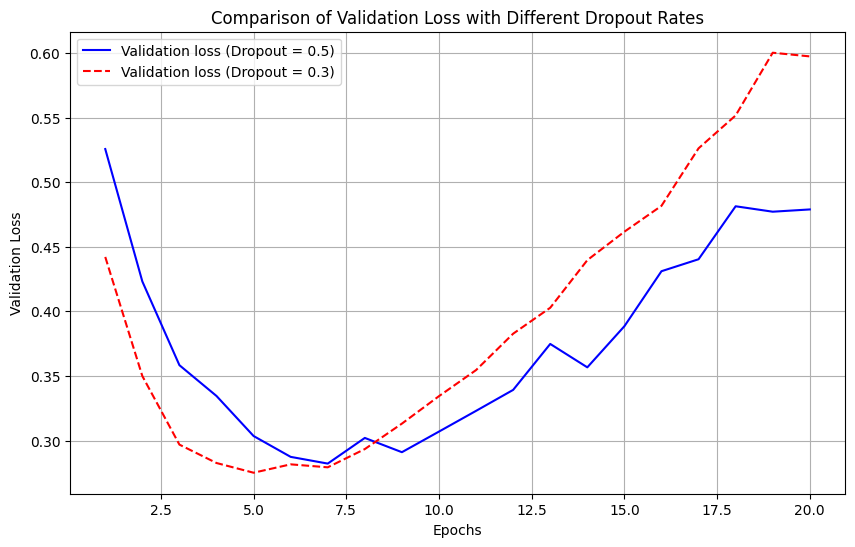

In [ ]:
import matplotlib.pyplot as plt

val_loss_dropout_05 = history_dropout_05.history["val_loss"]
val_loss_dropout_03 = history_dropout_03.history["val_loss"]

epochs = range(1, len(val_loss_dropout_05) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss_dropout_05, "b-", label="Validation loss (Dropout = 0.5)")
plt.plot(epochs, val_loss_dropout_03, "r--", label="Validation loss (Dropout = 0.3)")

plt.title("Comparison of Validation Loss with Different Dropout Rates")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 比較 dropout 0.5 and 0.3 的 val_loss 圖
# history_dropout_05
# history_dropout_03